# Extract the low frequency part of the companion for normalization.

---
Created by Chenyang in 2026.01.20

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os
pwd = os.getcwd()

import sys
src_path = os.path.join(pwd, 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

pwd

'/home/chenyangji/ESO/analysis/retrieval/retrieval_base'

## 0. Read the spectrum and plot

Data directory set to: /home/chenyangji/ESO/analysis/retrieval/retrieval_base/input


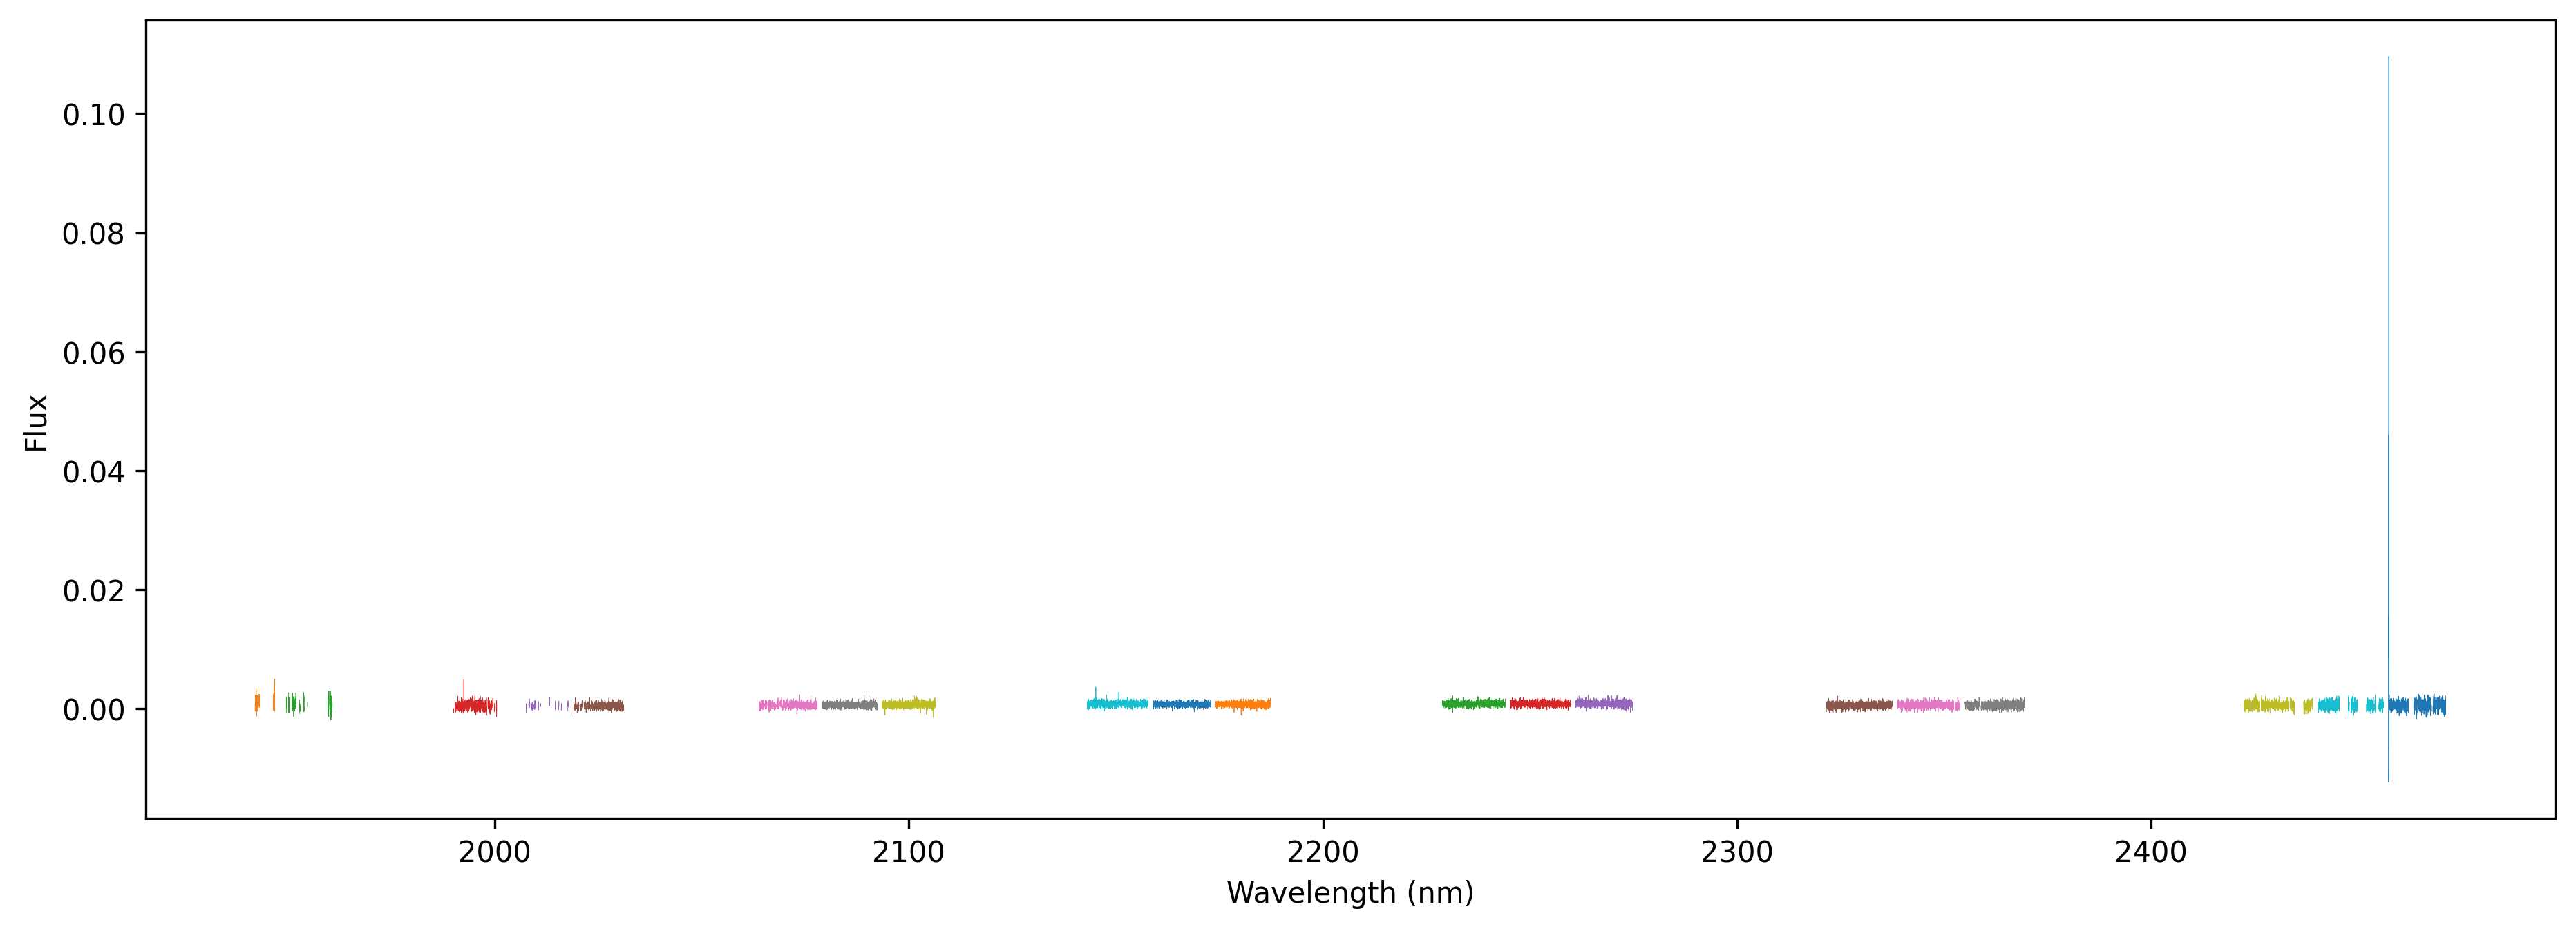

In [2]:
from src.data.loaders import load_crires_dat

wave, flux, err = load_crires_dat(  # micron -> nm
    target='CD-35_2722',
    # night="2022-12-31",
    night="2023-01-03",
    savename="starB",
    n_orders=7,
    n_dets=3,
    n_pixels=2048,
)

plt.figure(figsize=(15, 5), dpi=300)
for i in range(7):
    for j in range(3):
        plt.plot(wave[i, j, :], flux[i, j, :], linewidth=0.2)

# plt.ylim([0, 0.05])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
plt.show()

Remove bad pixels

In [3]:
# !src/data/preprocessing.py

def select_orders_chips(wave, flux, err, orders, dets, normalize=True):
    """
    Select specific orders and detectors, keeping the chip structure (not flattened).
    Each (order, det) combination becomes a chip.

    Parameters:
        wave (np.ndarray): wavelength [nm], shape (n_orders, n_dets, n_pixels)
        flux (np.ndarray): flux [original], shape (n_orders, n_dets, n_pixels)
        err (np.ndarray): error [original], shape (n_orders, n_dets, n_pixels)
        orders (list of int): index of orders to select, e.g., [5, 6]
        dets (list of int): index of detectors to select, e.g., [0, 1, 2]
        normalize (bool): whether to normalize the spectrum

    Returns:
        wave_chips (list): list of wavelength arrays, one per chip, shape (n_chips, n_pixels_per_chip)
        flux_chips (list): list of flux arrays, one per chip, shape (n_chips, n_pixels_per_chip)
        err_chips (list): list of error arrays, one per chip, shape (n_chips, n_pixels_per_chip)
        wave_ranges_chips (np.ndarray): wavelength ranges for each chip, shape (n_chips, 2) [min, max]
    """
    wave = np.asarray(wave)
    flux = np.asarray(flux)
    err  = np.asarray(err)

    # Select orders and detectors
    wave = wave[np.ix_(orders, dets)]
    flux = flux[np.ix_(orders, dets)]
    err  = err[np.ix_(orders, dets)]

    if normalize:
        # normalize each (order, detector) independently
        flux, err = simplistic_normalization(flux, err, axis=-1)

    # Reshape to (n_chips, n_pixels) where n_chips = n_orders * n_dets
    n_orders, n_dets, n_pixels = wave.shape
    n_chips = n_orders * n_dets
    
    wave_2d = wave.reshape(n_chips, n_pixels)
    flux_2d = flux.reshape(n_chips, n_pixels)
    err_2d  = err.reshape(n_chips, n_pixels)

    # Remove bad pixels that exceed 5 sigma (per chip)
    wave_chips = []
    flux_chips = []
    err_chips = []
    wave_ranges_chips = []
    
    for i in range(n_chips):
        # firstly remove the NaN/inf, and negative flux
        mask = ~np.isfinite(flux_2d[i]) | (flux_2d[i] < 0)
        # then remove the pixels with error larger than 3 times the median error
        mask = mask | (err_2d[i] > 5 * np.nanmedian(err_2d[i]))
        # then remove bad pixels, the flux is larger/smaller than 1*median flux
        mask = mask | (np.abs(flux_2d[i] - np.nanmedian(flux_2d[i])) > 1 * np.nanmedian(flux_2d[i]))
        
        wave_chip = wave_2d[i][~mask]
        flux_chip = flux_2d[i][~mask]
        err_chip = err_2d[i][~mask]
        
        # Only keep chips with valid data
        if len(wave_chip) > 0:
            wave_chips.append(wave_chip)
            flux_chips.append(flux_chip)
            err_chips.append(err_chip)
            wave_ranges_chips.append([wave_chip.min(), wave_chip.max()])
    
    wave_ranges_chips = np.array(wave_ranges_chips) if len(wave_ranges_chips) > 0 else np.array([]).reshape(0, 2)
    
    return wave_chips, flux_chips, err_chips, wave_ranges_chips


# !utils/normalization.py

def simplistic_normalization(flux, err=None, axis=-1):
    """
    Simplistic normalization using the median value. Each spectrum (e.g., each order in each detector) is divided by its median flux along the given axis, usually the pixel axis.
    * We pre-normalize each spectral segment by its median value and allow for an additional linear scaling parameter in the likelihood.

    Parameters:
        flux (np.ndarray): flux array to be normalized, shape (len(orders), len(dets), n_pixels)
        err (np.ndarray or None): error array associated with flux, shape (len(orders), len(dets), n_pixels)
        axis (int): axis along which to compute the median (default: last axis).

    Returns:
        flux_norm (np.ndarray): median-normalized flux, shape same as input flux
        err_norm (np.ndarray or None): median-normalized error (only if err is provided), shape same as input err
    """
    flux = np.asarray(flux).copy()

    if err is not None:
        err = np.asarray(err).copy()

    median = np.nanmedian(flux, axis=axis, keepdims=True)

    # protect against zero or NaN median
    bad = ~np.isfinite(median) | (median == 0)
    if np.any(bad):
        raise ValueError("Median normalization failed: zero or non-finite median encountered.")

    flux /= median

    if err is not None:
        err /= median
        return flux, err

    return flux


/tmp/ipykernel_290733/2609718294.py:55: RuntimeWarning: All-NaN slice encountered
  mask = mask | (np.abs(flux_2d[i] - np.nanmedian(flux_2d[i])) > 1 * np.nanmedian(flux_2d[i]))


IndexError: list index out of range

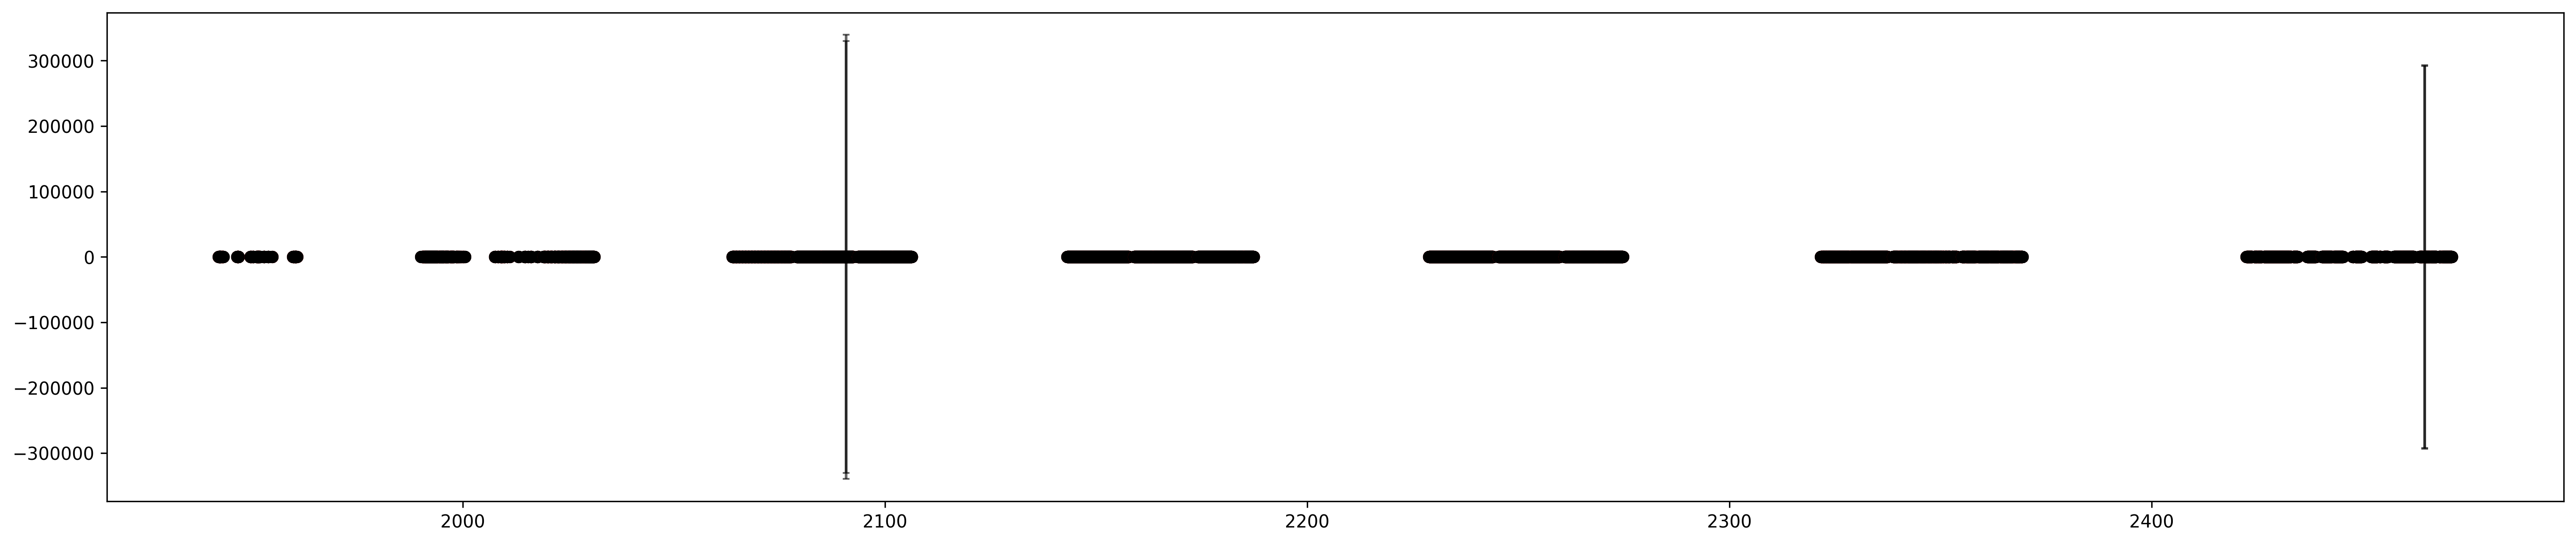

In [4]:
# orders=[6]
# dets=[2]
orders = [0,1,2,3,4,5,6]
# orders = [5,6]
dets = [0,1,2]

wave_chips, flux_chips, err_chips, wave_ranges_chips = select_orders_chips(
    wave, flux, err,
    orders=orders,
    dets=dets,
    normalize=False
)

plt.figure(figsize=(25, 5), dpi=300)
for i, iorder in enumerate(orders):
    for j, idet in enumerate(dets):
        plt.errorbar(wave[iorder,idet,:], flux[iorder,idet,:], err[iorder,idet,:], fmt='o', capsize=2, color='black', alpha=0.6)
        chip_idx = i*len(dets) + j
        plt.errorbar(wave_chips[chip_idx], flux_chips[chip_idx], yerr=err_chips[chip_idx], fmt='o', capsize=2, color='red', alpha=0.6)
plt.ylim([-0.02, 0.08])
# plt.ylim([0, 20])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
plt.show()

## 1. Extract the low-frequency part by convolving with a Gaussian profile

In [5]:
# copied from src.utils.spectral

import numpy as np
from scipy.ndimage import gaussian_filter
from astropy import units as u


def convolve_to_resolution(wave, flux, out_res, in_res=None):
    """
    Convolve spectrum to a target resolution, accounting for input resolution.
    
    This function handles the case where the input spectrum already has finite
    resolution. It uses error propagation to compute the additional broadening
    needed: 1/R_out² = 1/R_in² + 1/R_add²
    
    Args:
        wave (np.ndarray): Wavelength array [nm]
        flux (np.ndarray): Flux array
        out_res (float): Target output resolution (R = λ/Δλ)
        in_res (float, optional): Input resolution. If None, automatically computed
                                 from wavelength spacing.
    
    Returns:
        np.ndarray: Convolved flux array
    """
    # Handle astropy Quantity if needed
    if isinstance(wave, u.Quantity):
        wave = wave.to(u.Unit("nm")).value
    
    # Auto-compute input resolution if not provided
    if in_res is None:
        # Resolution from wavelength spacing: R = λ / Δλ
        in_res = np.mean(wave[:-1] / np.diff(wave))
    
    # Compute additional broadening needed
    # Using error propagation: 1/R_out² = 1/R_in² + 1/R_add²
    # So: R_add = 1/√(1/R_out² - 1/R_in²)
    # And sigma_LSF = λ/(R_add × 2√(2ln2))
    sigma_LSF = np.sqrt(1.0 / out_res**2 - 1.0 / in_res**2) / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    
    # Compute wavelength spacing (log-spaced grid)
    spacing = np.mean(2.0 * np.diff(wave) / (wave[1:] + wave[:-1]))
    
    # Convert to pixels for gaussian filter
    sigma_LSF_gauss_filter = sigma_LSF / spacing
    
    # Handle NaN values
    out_flux = np.full_like(flux, np.nan)
    nans = np.isnan(flux)
    
    # Apply gaussian filter only to non-NaN values
    if not nans.all():
        out_flux[~nans] = gaussian_filter(
            flux[~nans],
            sigma=sigma_LSF_gauss_filter,
            mode='reflect'
        )
    
    return out_flux


In [6]:
def remove_deep_lines_convolve_to_resolution(wave, flux, err, perc=25, sigma=2, out_res=150):
    """
    1. 在 flux 中找到最小 perc% 的点（深吸收线）
    2. 仅在求 continuum 时忽略这些点（不改原始 flux/err）
    3. 用忽略深线的谱线去卷积到目标分辨率 out_res
    4. 返回的是：wave, continuum(conv_flux), 原始 err
    """
    wave = np.asarray(wave)
    flux = np.asarray(flux)
    err  = None if err is None else np.asarray(err)

    # 只在有限值上统计分位数
    valid = np.isfinite(flux)
    if not np.any(valid):
        return wave, flux, err

    # check if one of perc or sigma exists
    if perc is not None:
        # 找到“最小 perc%”的阈值
        q = np.nanpercentile(flux[valid], perc)
    elif sigma is not None:
        # 找到median - n*sigma的点
        q = np.nanmedian(flux[valid]) - sigma * np.nanstd(flux[valid])
    else:
        raise ValueError("Either perc or sigma must be provided")

    # 仅用于求 continuum 的副本：把深线点标为 NaN
    flux_for_cont = flux.copy()
    mask_deep = flux_for_cont < q
    flux_for_cont[mask_deep] = np.nan

    # 卷积到目标分辨率（内部会忽略 NaN）
    conv_flux = convolve_to_resolution(wave, flux_for_cont, out_res=out_res)

    # 如果卷积结果里有 NaN（比如某段全被掩掉），用插值补齐，避免后面归一化再产生 NaN
    bad = ~np.isfinite(conv_flux)
    good = np.isfinite(conv_flux)
    if np.any(bad) and np.any(good):
        conv_flux[bad] = np.interp(wave[bad], wave[good], conv_flux[good])

    return wave, conv_flux, err

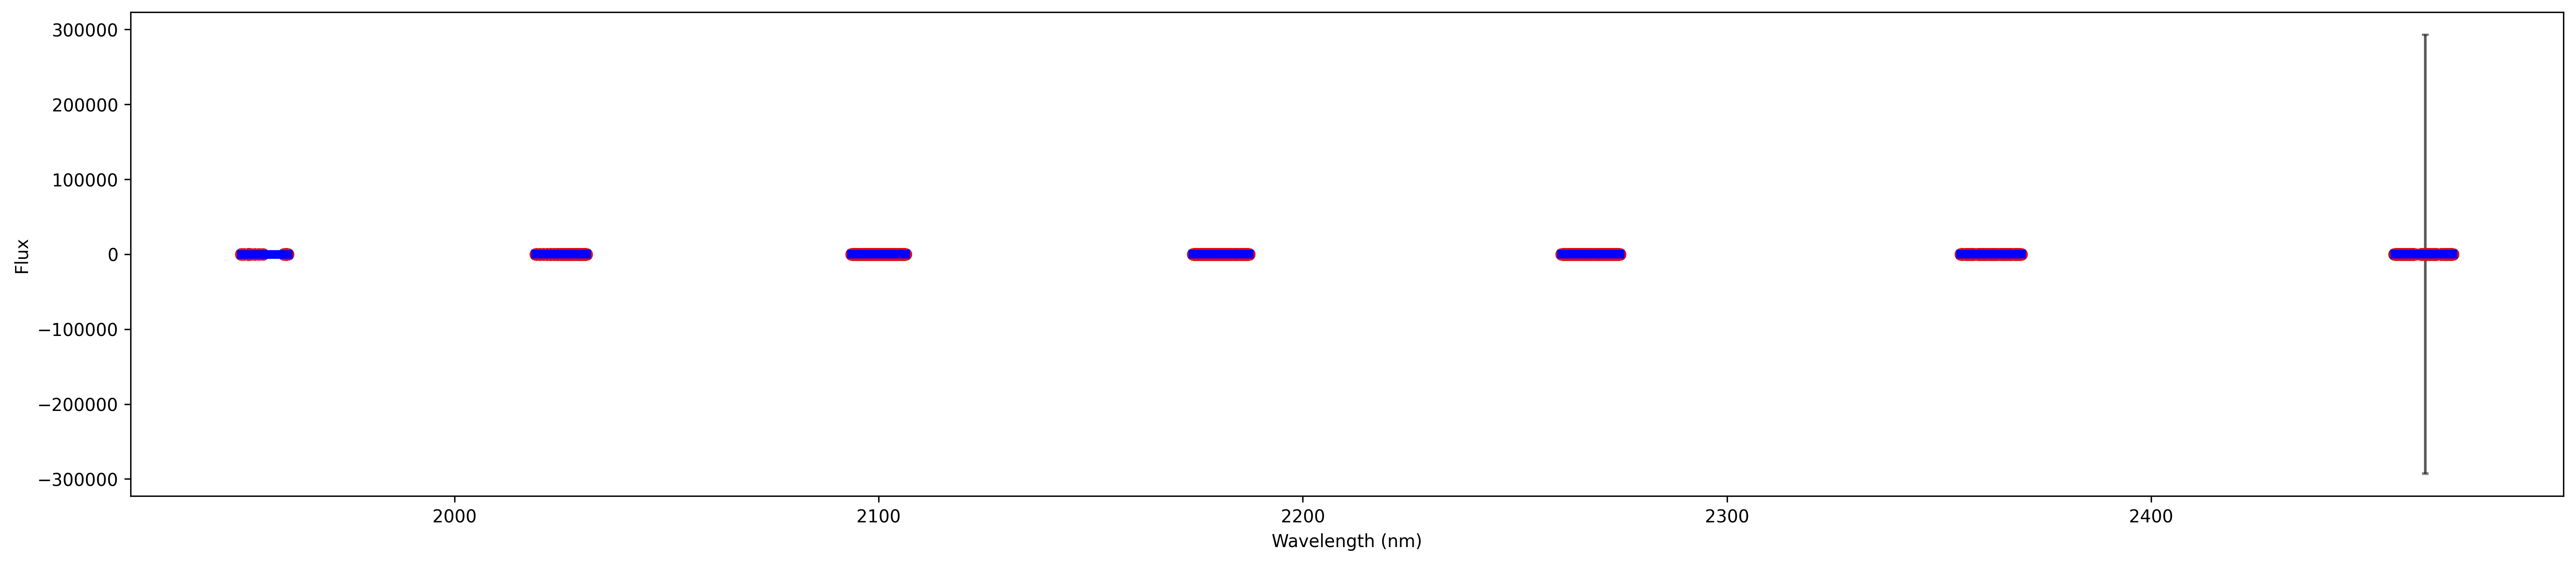

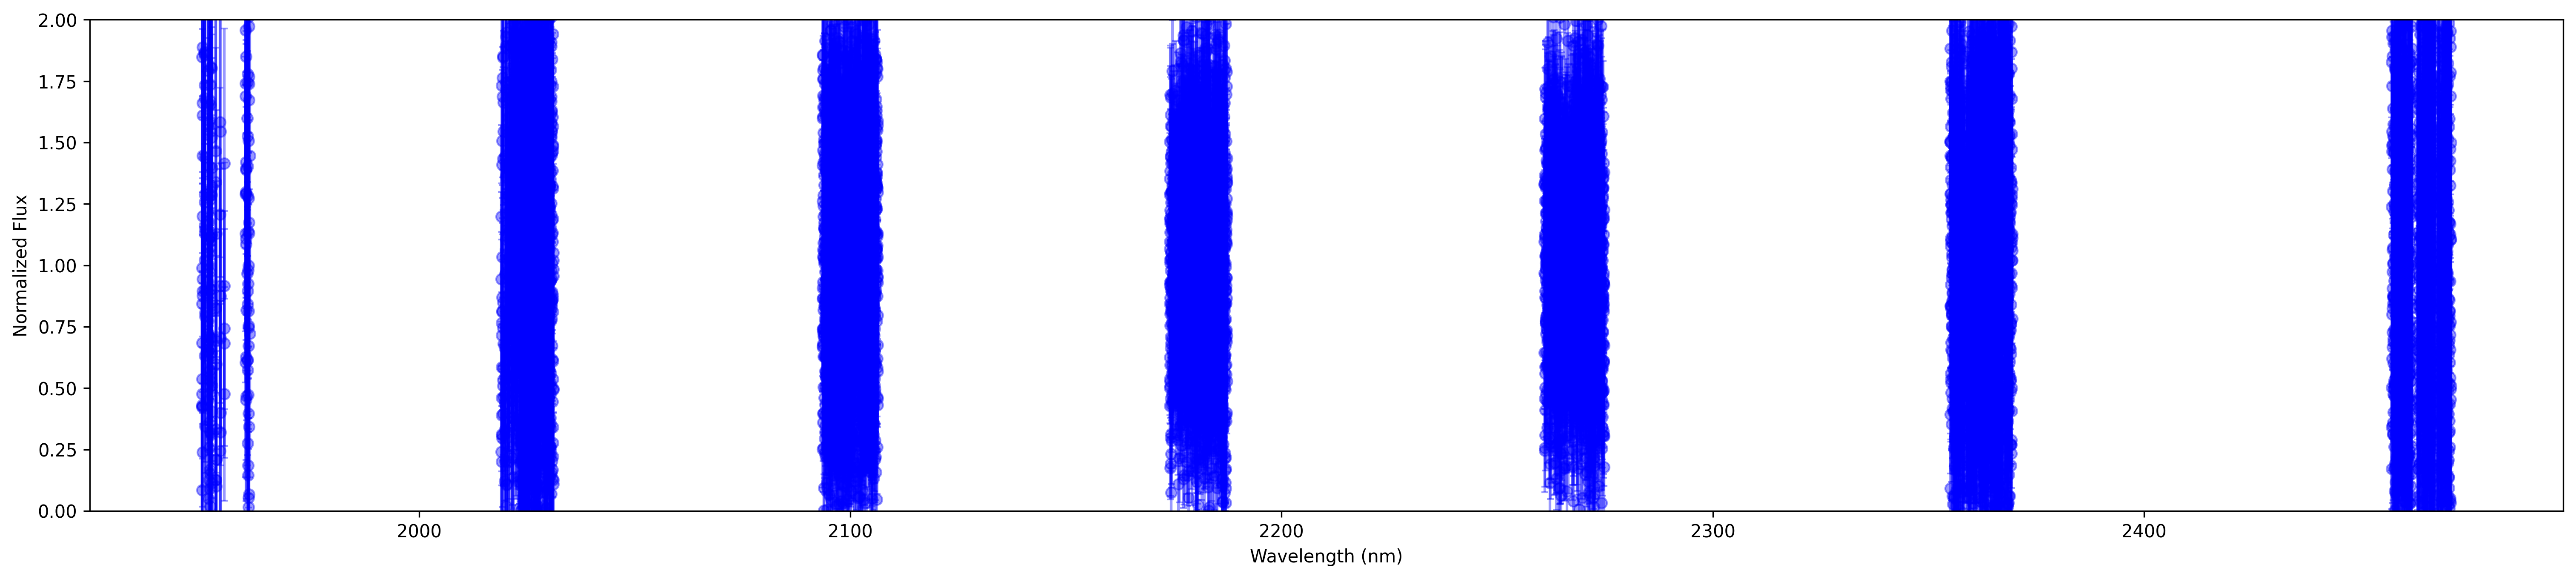

In [7]:
# from src.utils.spectral import convolve_to_resolution, instr_broadening

# orders=[6]
# orders = [5,6]
orders = [0,1,2,3,4,5,6]
dets = [2]
# dets=[1]

wave_chips, flux_chips, err_chips, wave_ranges_chips = select_orders_chips(
    wave, flux, err,
    orders=orders,
    dets=dets,
    normalize=False
)

res_LFP = 100
flux_LFP = []
flux_LFP_norm = []
err_LFP_norm = []
# plot the LFP
plt.figure(figsize=(25, 5), dpi=300)
for i, iorder in enumerate(orders):
    for j, idet in enumerate(dets):
        plt.errorbar(wave[iorder,idet,:], flux[iorder,idet,:], err[iorder,idet,:], fmt='o', capsize=2, color='black', alpha=0.4, label='original data points')
        chip_idx = i*len(dets) + j
        plt.errorbar(wave_chips[chip_idx], flux_chips[chip_idx], yerr=err_chips[chip_idx], fmt='o', capsize=2, color='red', alpha=0.4, label='masked data points')
        flux_LFP_chip = convolve_to_resolution(wave_chips[chip_idx], flux_chips[chip_idx], out_res=res_LFP)
        # normalize using the LFP
        flux_LFP_norm_chip = flux_chips[chip_idx] / flux_LFP_chip
        err_LFP_norm_chip = err_chips[chip_idx] / flux_LFP_chip
        plt.plot(wave_chips[chip_idx], flux_LFP_chip, color='blue', linewidth=5, zorder=10, label='low-frequency part')
        flux_LFP.append(flux_LFP_chip)
        flux_LFP_norm.append(flux_LFP_norm_chip)
        err_LFP_norm.append(err_LFP_norm_chip)
# plt.ylim([-0.0, 0.08])
# plt.ylim([0, 2])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux')
# plt.legend()
plt.show()

# plot the normalized spectrum
plt.figure(figsize=(25, 5), dpi=300)
for i in range(len(flux_LFP_norm)):
    plt.errorbar(wave_chips[i], flux_LFP_norm[i], err_LFP_norm[i], fmt='o', capsize=2, color='blue', alpha=0.4, label='normalized spectrum using LFP')
    # plt.plot(wave_chips[i], flux_LFP_norm[i], color='blue', linewidth=5, zorder=10)

# plt.ylim([-0.02, 0.08])
plt.ylim([0, 2])
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized Flux')
# plt.legend()
plt.show()


Different ways to extract the low-frequency part:
- Gaussian / median smoothing
- Fourier filtering
- spline decomposition

In [8]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def simplistic_normalization(wl, flux, err, axis=-1):
    """
    Simplistic normalization using the median value. Each spectrum (e.g., each order in each detector) is divided by its median flux along the given axis, usually the pixel axis.
    """
    flux = np.asarray(flux).copy()
    if err is not None:
        err = np.asarray(err).copy()
    median = np.nanmedian(flux, axis=axis)
    # protect against zero or NaN median
    bad = ~np.isfinite(median) | (median == 0)
    if np.any(bad):
        raise ValueError("Median normalization failed: zero or non-finite median encountered.")

    return wl.copy(), median*np.ones_like(flux), err.copy()

    

def gaussian_lfp(wl, flux, err, sigma_px=150):
    """
    Gaussian low-frequency pattern extraction
    sigma_px : Gaussian sigma in *pixel space*
    """

    flux_lfp = gaussian_filter1d(flux, sigma=sigma_px, mode="nearest")

    # error propagation: convolution with normalized kernel
    err_lfp = gaussian_filter1d(err**2, sigma=sigma_px, mode="nearest")
    err_lfp = np.sqrt(err_lfp)

    return wl.copy(), flux_lfp, err_lfp

def fourier_lfp(wl, flux, err, frac_cut=0.05):
    """
    Fourier low-pass filtering in wavelength (pixel) space
    frac_cut : fraction of lowest Fourier modes to keep (e.g. 0.05 = 5%)
    """

    n = len(flux)

    # FFT assumes uniform sampling (pixel space)
    ft_flux = np.fft.rfft(flux)
    ft_err2 = np.fft.rfft(err**2)

    k_cut = int(len(ft_flux) * frac_cut)

    ft_flux[k_cut:] = 0.0
    ft_err2[k_cut:] = 0.0

    flux_lfp = np.fft.irfft(ft_flux, n=n)
    err_lfp = np.sqrt(np.fft.irfft(ft_err2, n=n))

    return wl.copy(), flux_lfp, err_lfp

from scipy.interpolate import LSQUnivariateSpline

def spline_lfp(wl, flux, err, knot_spacing_px=40, k=3):
    """
    Spline decomposition low-frequency pattern
    knot_spacing_px : spacing between spline knots in pixel space
    k : spline order (3 = cubic)
    """

    n = len(wl)

    # knots in pixel space, then mapped to wavelength
    pix = np.arange(n)
    knot_pix = np.arange(knot_spacing_px, n - knot_spacing_px, knot_spacing_px)
    knot_wl = np.interp(knot_pix, pix, wl)

    spline = LSQUnivariateSpline(
        wl, flux, t=knot_wl, w=1.0 / err, k=k
    )

    flux_lfp = spline(wl)

    # approximate error propagation
    # (strict Bayesian treatment would marginalize instead)
    err_lfp = np.full_like(err, np.std(flux - flux_lfp))

    return wl.copy(), flux_lfp, err_lfp

import numpy as np
from scipy.ndimage import median_filter

def median_highpass(wl, flux, err, window=500):
    """
    Median high-pass filtering in wavelength (pixel) space.

    This follows the KPIC-style normalization:
    - estimate low-frequency component with a median filter
    - subtract it from the spectrum
    """

    # --- sanity checks ---
    wl = np.asarray(wl)
    flux = np.asarray(flux)
    err = np.asarray(err)

    if window % 2 == 0:
        window += 1  # median filter prefers odd window size

    # --- estimate low-frequency component ---
    low_freq = median_filter(flux, size=window, mode="reflect")

    # --- high-pass: subtract low-frequency component ---
    flux_hp = flux - low_freq

    # --- error handling ---
    # Following common practice (e.g. KPIC),
    # we do not propagate the covariance introduced by filtering.
    err_hp = err.copy()

    return wl.copy(), low_freq, err_hp

def median_highpass_normalization(wave, flux, err=None, window=600):
    """
    Normalize flux using median high-pass filtering.
    
    This follows the KPIC-style normalization:
    - estimate low-frequency component with a median filter
    - normalize by dividing flux by the low-frequency component
    
    Parameters:
        wave (np.ndarray): wavelength array [nm], shape (n_pixels,)
        flux (np.ndarray): flux array to be normalized, shape (n_pixels,)
        err (np.ndarray or None): error array associated with flux, shape (n_pixels,)
        window (int): window size for median filter (default: 600 for CRIRES+ K band, or equivalent for 5nm)
    
    Returns:
        flux_norm (np.ndarray): normalized flux (flux / low_freq), shape (n_pixels,)
        err_norm (np.ndarray or None): normalized error (only if err is provided), shape (n_pixels,)
    """
    flux = np.asarray(flux).copy()
    wave = np.asarray(wave)
    
    if err is not None:
        err = np.asarray(err).copy()
    
    # Ensure window is odd
    if window % 2 == 0:
        window += 1
    
    # Estimate low-frequency component with median filter
    low_freq = median_filter(flux, size=window, mode="reflect")
    
    # Protect against zero or NaN low_freq
    bad = ~np.isfinite(low_freq) | (low_freq == 0)
    if np.any(bad):
        # Replace bad values with median of good values
        good_low_freq = low_freq[~bad]
        if len(good_low_freq) > 0:
            low_freq[bad] = np.nanmedian(good_low_freq)
        else:
            # Fallback to simplistic normalization
            low_freq = np.full_like(low_freq, np.nanmedian(flux))
    
    # # Normalize: divide by low-frequency component
    # flux_norm = flux / low_freq
    
    # if err is not None:
    #     err_norm = err / low_freq
    #     return flux_norm, err_norm
    
    # return flux_norm
    return wave.copy(), low_freq, err.copy()


import numpy as np
from scipy.signal import savgol_filter
def savgol_lfp(wave, flux, err=None, window_length=301, polyorder=3):
    """
    Savitzky-Golay low-frequency pattern extraction

    window_length : SG window length in *pixel space* (must be odd)
    polyorder     : polynomial order for local fitting
    """

    flux = np.asarray(flux).copy()
    wave = np.asarray(wave)

    # low-frequency pattern via local polynomial reconstruction
    flux_lfp = savgol_filter(
        flux,
        window_length=window_length,
        polyorder=polyorder,
        mode="interp"
    )

    flux_norm = flux / flux_lfp

    if err is not None:
        err_norm = err / flux_lfp
        return wave, flux_lfp, err.copy()

    return wave, flux_lfp

# remove the deep lines, and then convolve to R=150


In [14]:
# orders=[2,3]
orders = [2,3,4,5,6]
# dets = [1]
dets=[0,1,2]

wave_chips, flux_chips, err_chips, wave_ranges_chips = select_orders_chips(
    wave, flux, err,
    orders=orders,
    dets=dets,
    normalize=False
)

lfp_methods = {
    "simplistic_normalization": lambda wl, f, e: simplistic_normalization(
        wl, f, e
    ),
    # "R=150 convolution": lambda wl, f, e: (
    #     wl,
    #     convolve_to_resolution(wl, f, out_res=500),
    #     e  # 这里只是画图，不严格传播
    # ),
    # "Remove deep lines and convolve to R=150": lambda wl, f, e: remove_deep_lines_convolve_to_resolution(
    #     # wl, f, e, sigma=5, out_res=150
    #     wl, f, e, perc=3, out_res=150
    # ),
    # "Gaussian smoothing": lambda wl, f, e: gaussian_lfp(
    #     wl, f, e, sigma_px=200
    # ),
    # "Fourier filtering": lambda wl, f, e: fourier_lfp(
    #     wl, f, e, frac_cut=0.002
    # ),
    # "Spline decomposition": lambda wl, f, e: spline_lfp(
    #     wl, f, e, knot_spacing_px=1000
    # ),
    # "Median high-pass": lambda wl, f, e: median_highpass(
    #     wl, f, e, window=600
    # ),
    # "Median high-pass normalization": lambda wl, f, e: median_highpass_normalization(
    #     wl, f, e, window=2000
    # ),
    # "Savitzky-Golay": lambda wl, f, e: savgol_lfp(
    #     wl, f, e, window_length=1501, polyorder=3
    # ),
}

lfp_labels = {
    "simplistic_normalization": "simplistic normalization",
    "Remove deep lines and convolve to R=150": "Remove deep lines and convolve to R=150",
    "R=150 convolution": "R=150 convolution",
    "Gaussian smoothing": "Gaussian smoothing, sigma=200pix",
    "Fourier filtering": "Fourier filtering",
    "Spline decomposition": "Spline decomposition",
    "Median high-pass": "Median high-pass, 600pix ~ 5nm",
    "Median high-pass normalization": "Median high-pass, 1000pix ~ 8nm",
    "Savitzky-Golay": "Savitzky-Golay, 1301pix",
}

lfp_colors = {
    "simplistic_normalization": "pink",
    "Remove deep lines and convolve to R=150": "salmon",
    "R=150 convolution": "blue",
    "Gaussian smoothing": "red",
    "Fourier filtering": "green",
    "Spline decomposition": "purple",
    "Median high-pass": "orange",
    "Median high-pass normalization": "cyan",
    "Savitzky-Golay": "magenta",
}


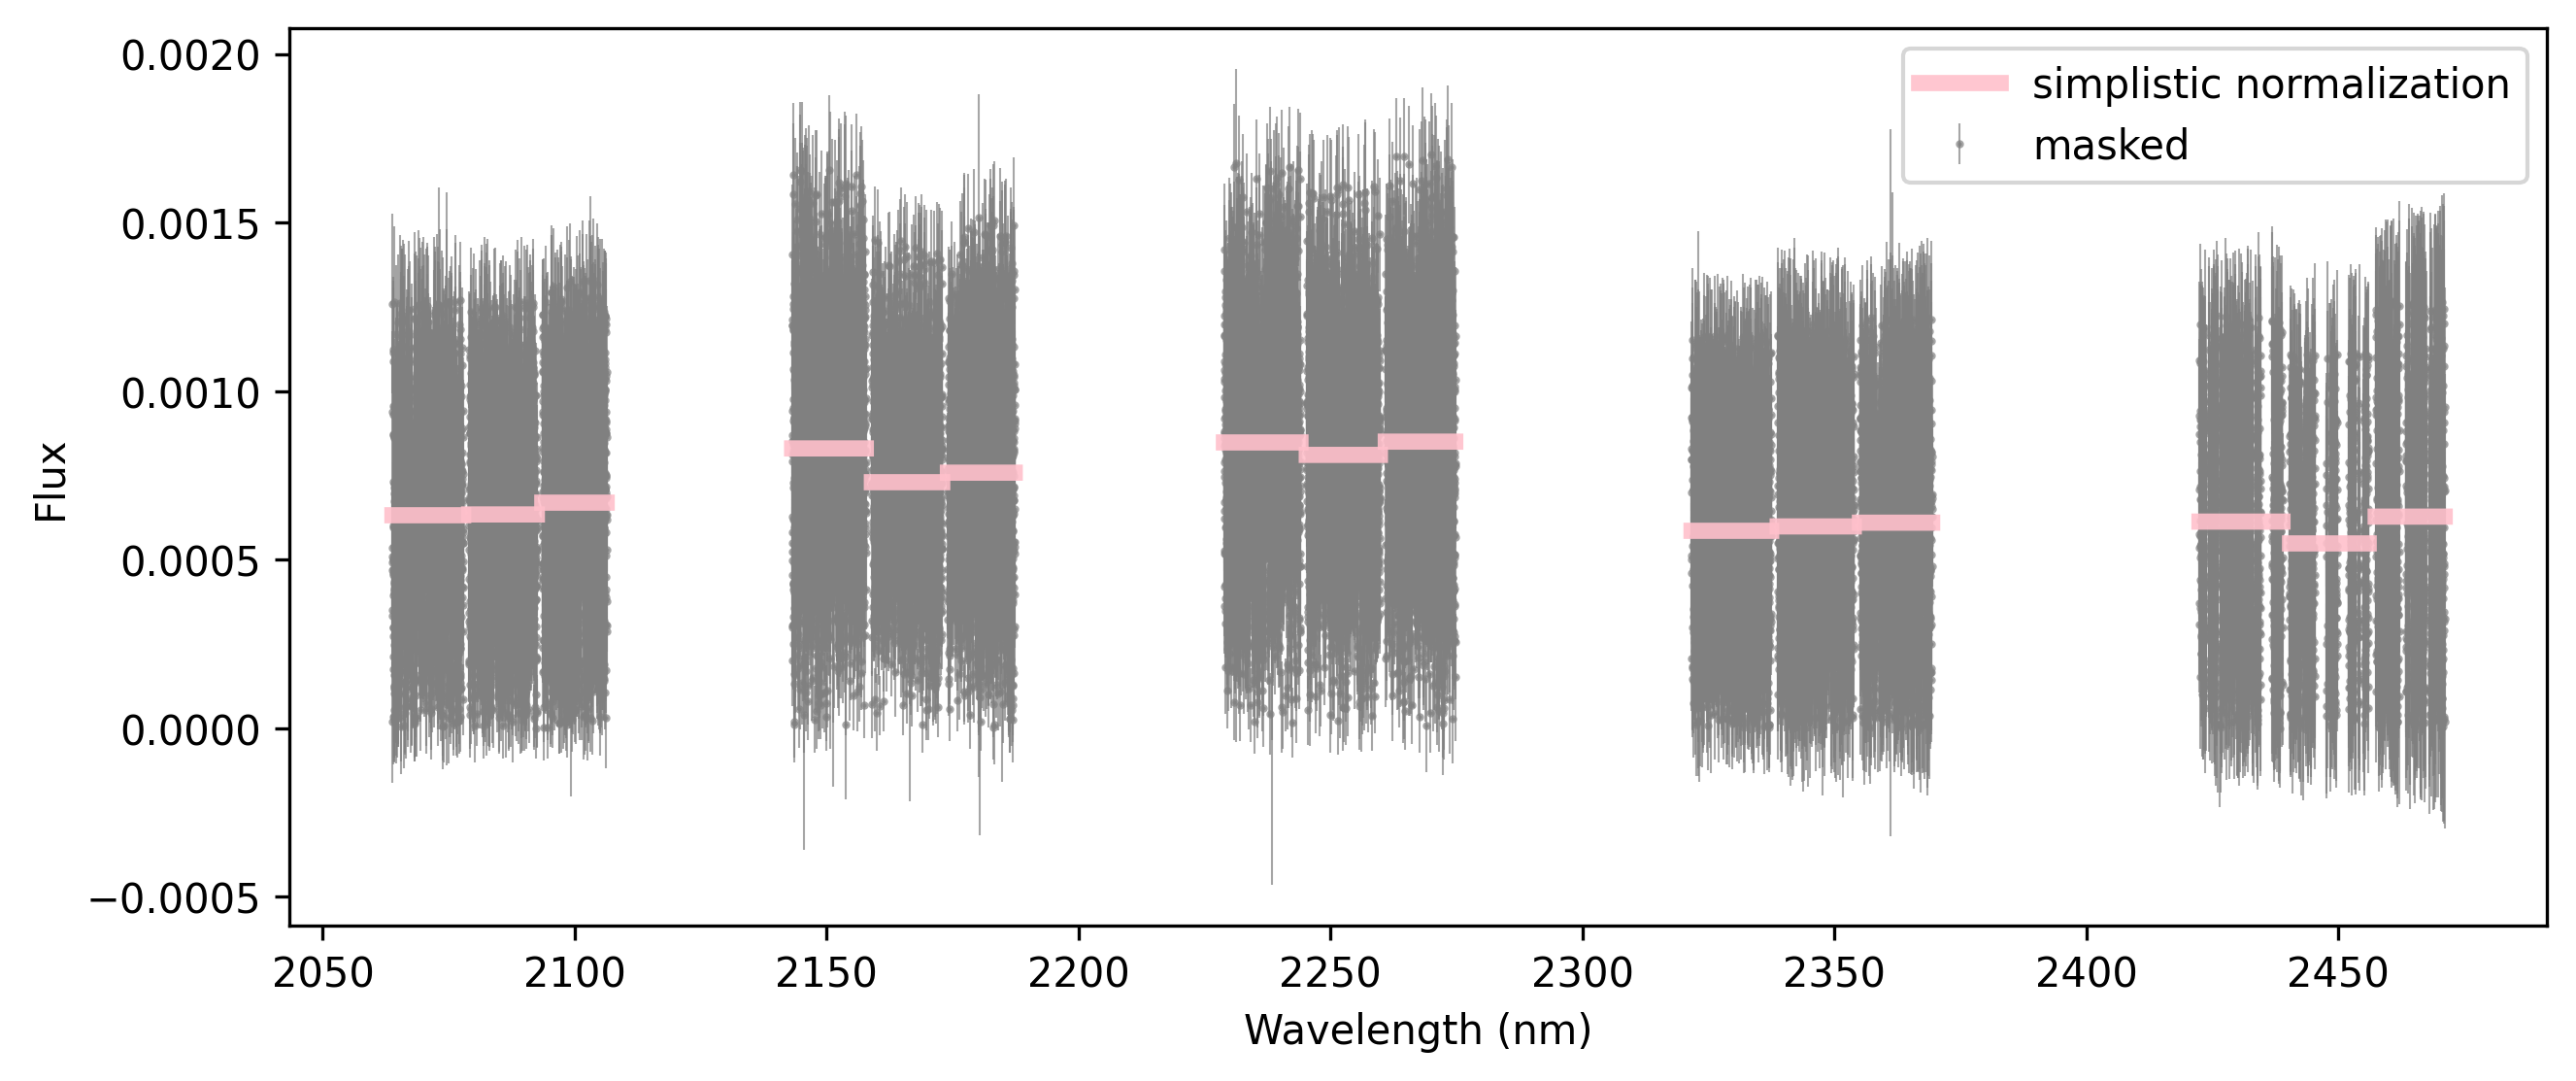

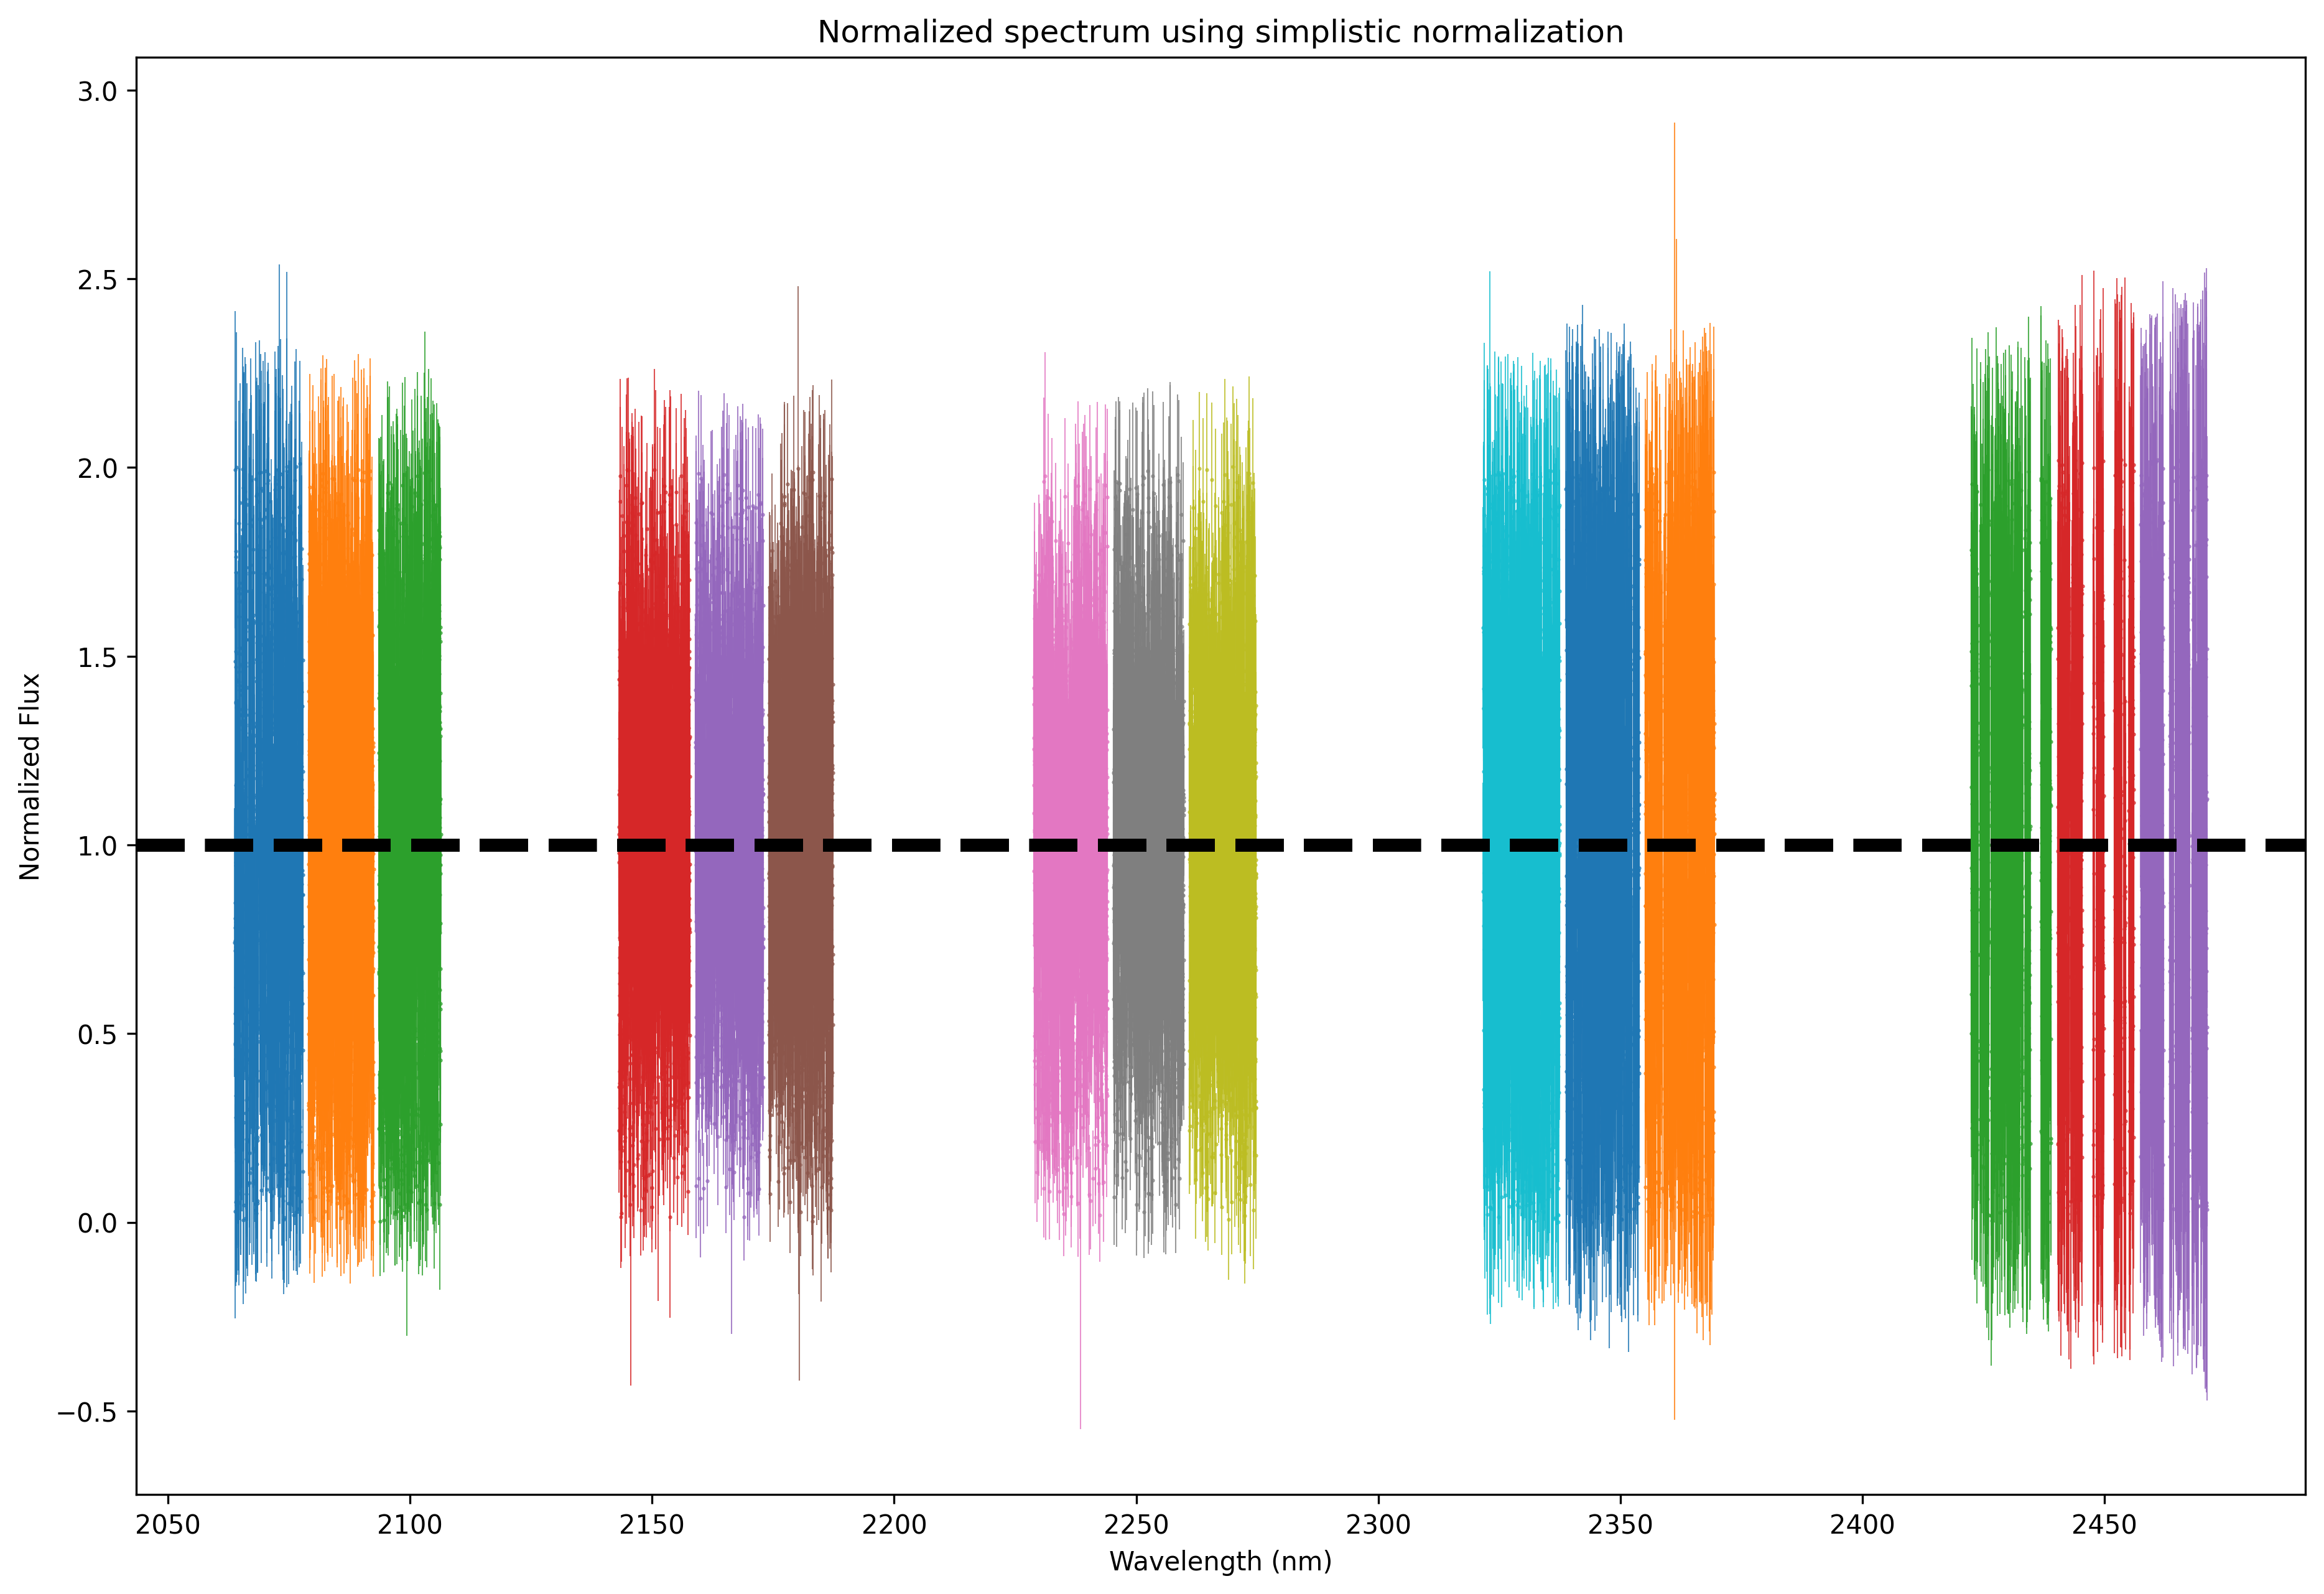

In [15]:
plt.figure(figsize=(10, 4), dpi=300)
for i, iorder in enumerate(orders):
    for j, idet in enumerate(dets):

        chip_idx = i * len(dets) + j
        wl = wave_chips[chip_idx]
        f = flux_chips[chip_idx]
        e = err_chips[chip_idx]

        # 原始 & mask 后数据
        # plt.errorbar(
        #     wave[iorder, idet, :],
        #     flux[iorder, idet, :],
        #     err[iorder, idet, :],
        #     fmt='o', color='black', alpha=0.1, markersize=1, elinewidth=0.5, 
        #     label='original' if i == 0 and j == 0 else None,
        # )

        plt.errorbar(
            wl, f, yerr=e,
            fmt='o', color='grey', alpha=0.7, markersize=1, elinewidth=0.5, 
            label='masked' if i == 0 and j == 0 else None,
        )

        # 各种 LFP
        for name, method in lfp_methods.items():
            wl_lfp, f_lfp, e_lfp = method(wl, f, e)
            plt.plot(
                wl_lfp, f_lfp,
                linewidth=4,
                # only note the label of the first order/detector
                label=lfp_labels[name] if i == 0 and j == 0 else None,
                color=lfp_colors[name],
                alpha=0.9,
                zorder=10,
            )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
# plt.title(f"Order {iorder}, Det {idet}")
# plt.ylim([-0.0, 0.04])
plt.legend()
plt.show()

for name, method in lfp_methods.items():

    plt.figure(figsize=(15, 10), dpi=300)

    for chip_idx in range(len(wave_chips)):

        wl = wave_chips[chip_idx]
        f = flux_chips[chip_idx]
        e = err_chips[chip_idx]

        wl_lfp, f_lfp, e_lfp = method(wl, f, e)

        f_norm = f / f_lfp
        e_norm = e / f_lfp

        # f_norm = f - f_lfp
        # e_norm = e

        plt.errorbar(
            wl, f_norm, yerr=e_norm,
            fmt='o', alpha=0.8, markersize=0.5, elinewidth=0.5,
        )

        plt.axhline(1, color='black', linewidth=5, linestyle='--', alpha=0.7, zorder=5)

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Normalized Flux")
    plt.title(f"Normalized spectrum using {lfp_labels[name]}")

    plt.show()


In [13]:
# print the relative wavelength difference of 500 pixels
pix_diff = 600
window = np.median(np.array([wave_chips[0][i+pix_diff] - wave_chips[0][i] for i in range(len(wave_chips[0])-pix_diff)]))
print(f"The median wavelength difference of {pix_diff} pixels is {window} nm, or {round(window/1000, 6)} micron")


The median wavelength difference of 600 pixels is 5.736889490178783 nm, or 0.005737 micron


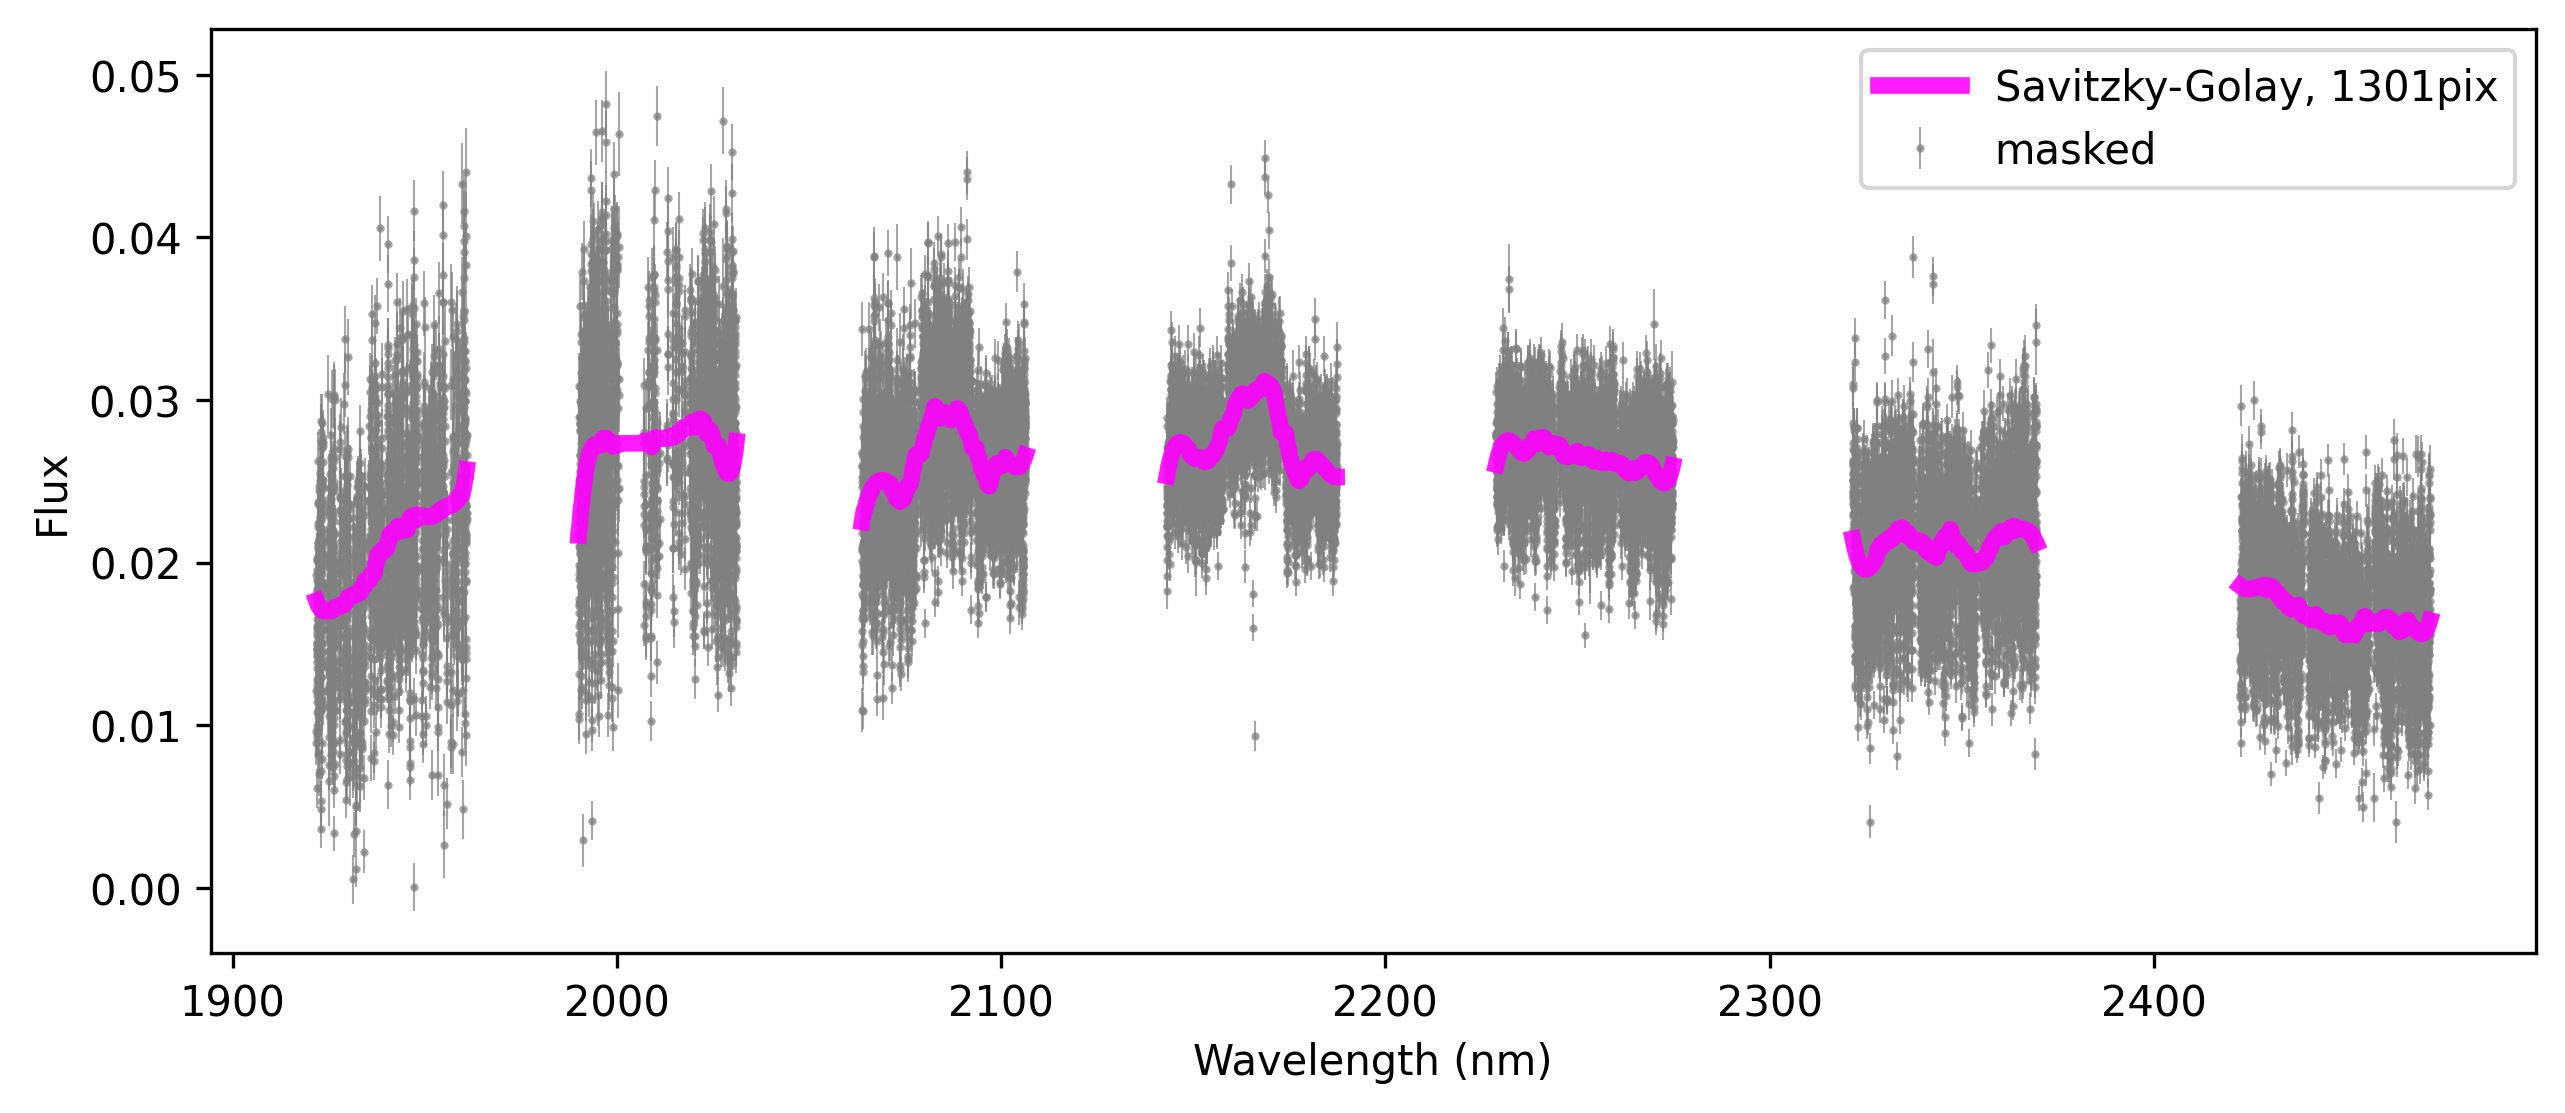

In [16]:
plt.figure(figsize=(10, 4), dpi=300)

n_dets = len(dets)

for i, iorder in enumerate(orders):
    # 注意这里用 i，而不是 iorder 本身
    chip_start = i * n_dets
    chip_end   = (i + 1) * n_dets

    wl_list = wave_chips[chip_start:chip_end]
    f_list  = flux_chips[chip_start:chip_end]
    e_list  = err_chips[chip_start:chip_end]

    # 原始 / masked 数据
    for j in range(n_dets):
        wl_chip = wl_list[j]
        f_chip  = f_list[j]
        e_chip  = e_list[j]

        plt.errorbar(
            wl_chip, f_chip, yerr=e_chip,
            fmt='o', color='grey', alpha=0.7, markersize=1, elinewidth=0.5,
            label='masked' if i == 0 and j == 0 else None,
        )

    # 把该 order 的 3 个 det 拼成一条长谱，按 order 级别做 LFP
    wl_all = np.concatenate(wl_list)
    f_all  = np.concatenate(f_list)
    e_all  = np.concatenate(e_list)

    for name, method in lfp_methods.items():
        wl_lfp_all, f_lfp_all, e_lfp_all = method(wl_all, f_all, e_all)
        plt.plot(
            wl_lfp_all, f_lfp_all,
            linewidth=4,
            label=lfp_labels[name] if i == 0 else None,
            color=lfp_colors[name],
            alpha=0.9,
            zorder=10,
        )

plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.legend()
plt.show()

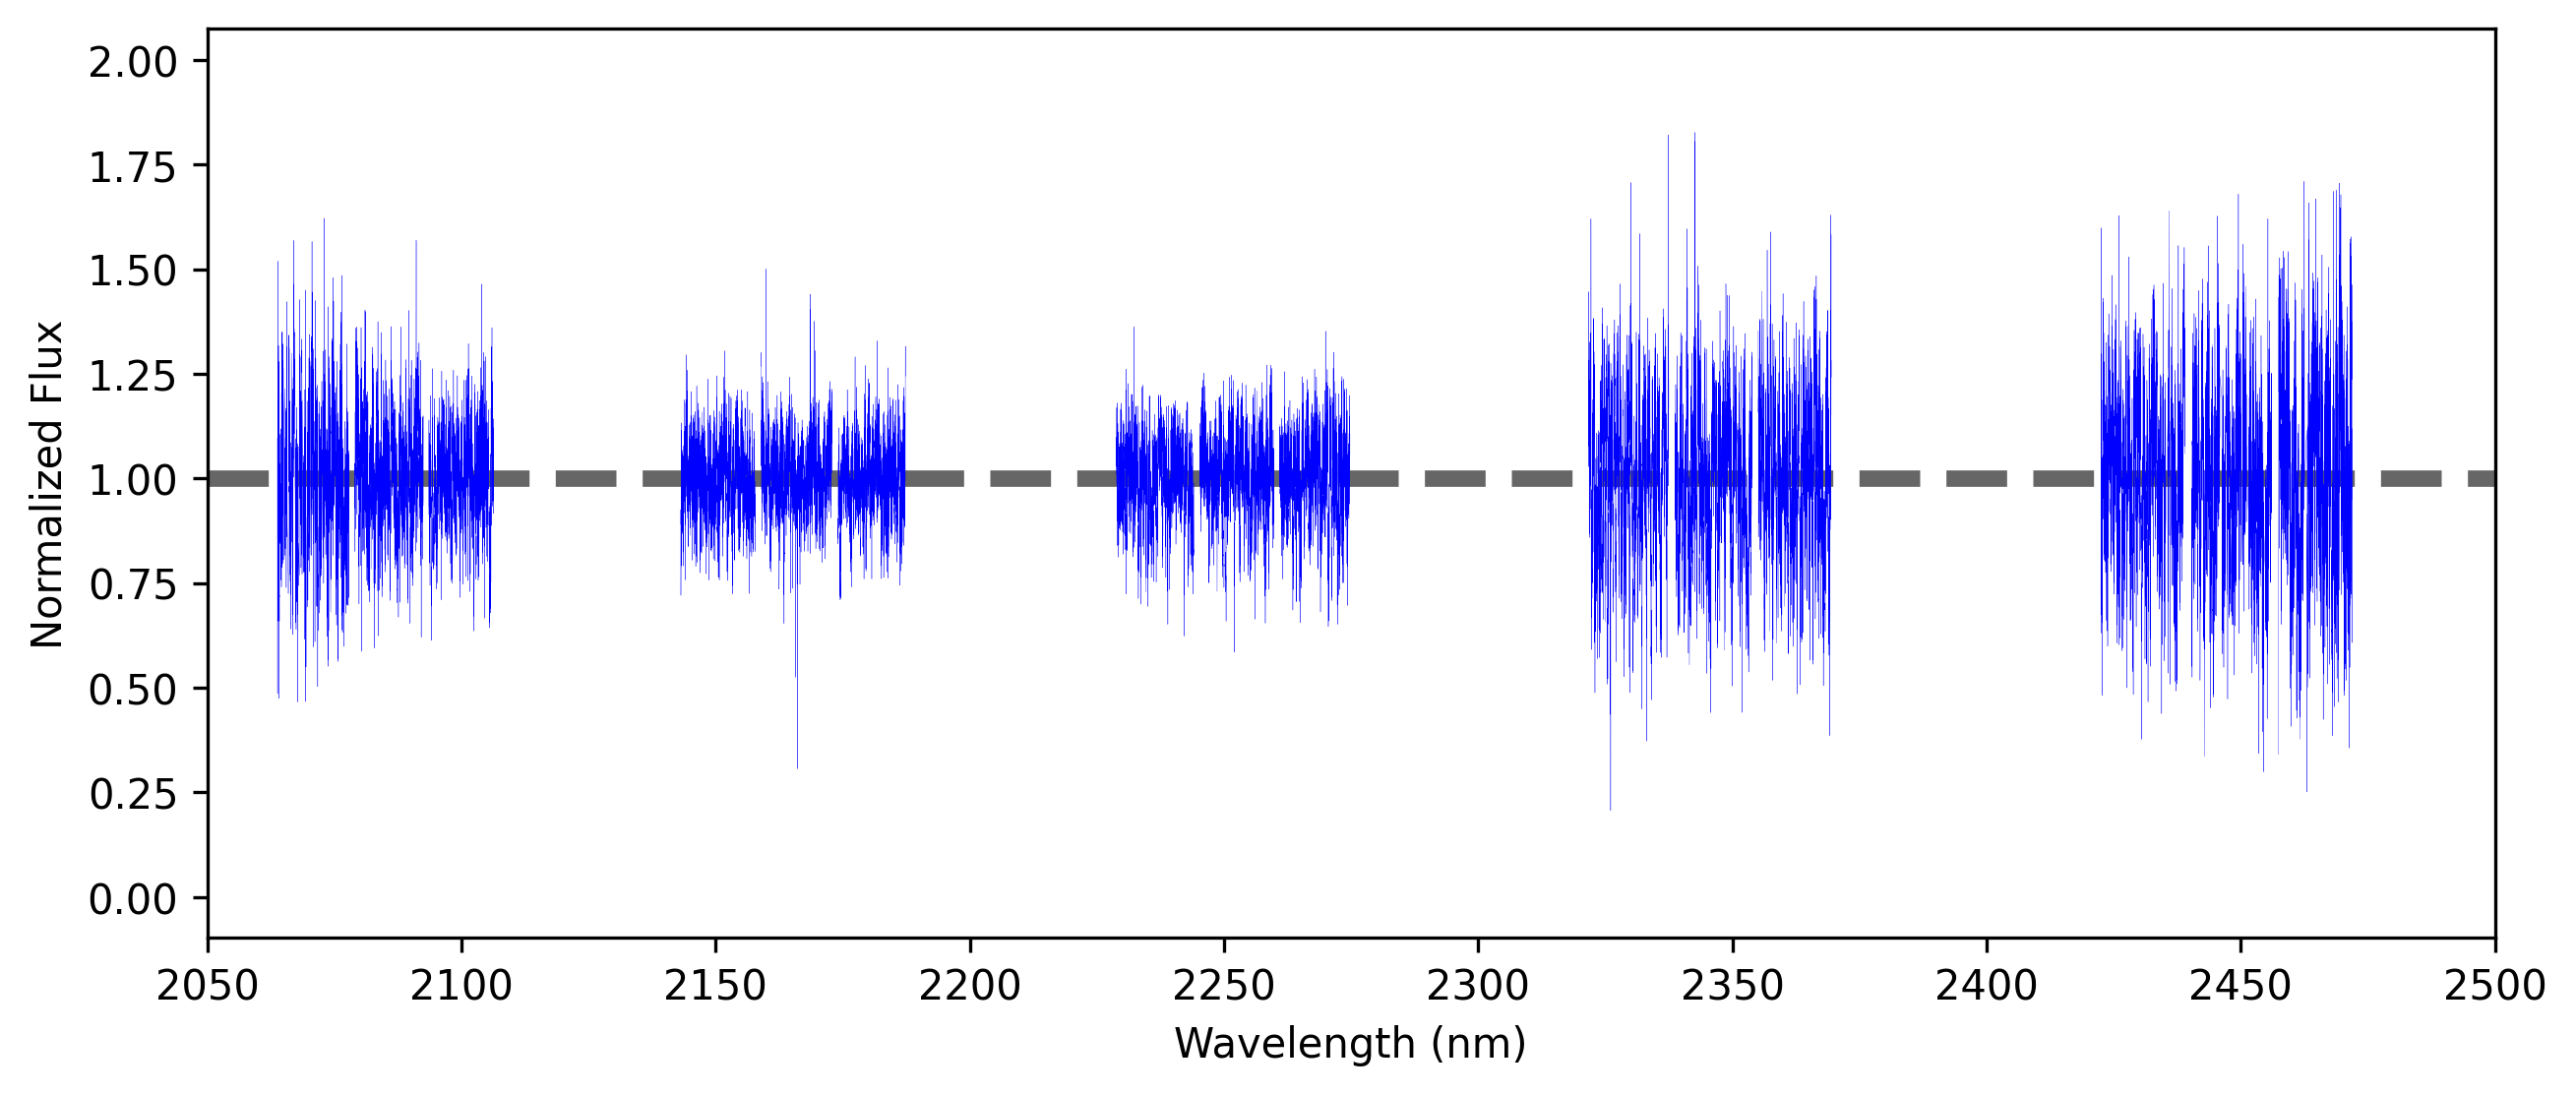

In [24]:
n_dets = len(dets)

for name, method in lfp_methods.items():

    plt.figure(figsize=(10, 4), dpi=300)

    for i, iorder in enumerate(orders):
        chip_start = i * n_dets
        chip_end   = (i + 1) * n_dets

        wl_list = wave_chips[chip_start:chip_end]
        f_list  = flux_chips[chip_start:chip_end]
        e_list  = err_chips[chip_start:chip_end]

        # 整个 order 上做 LFP
        wl_all = np.concatenate(wl_list)
        f_all  = np.concatenate(f_list)
        e_all  = np.concatenate(e_list)

        wl_lfp_all, f_lfp_all, e_lfp_all = method(wl_all, f_all, e_all)

        # 把 LFP 按 det 切回 3 段，用于归一化
        lengths = [len(w) for w in wl_list]
        split_indices = np.cumsum(lengths)[:-1]
        f_lfp_chips = np.split(f_lfp_all, split_indices)

        for j in range(n_dets):
            wl_chip = wl_list[j]
            f_chip  = f_list[j]
            e_chip  = e_list[j]
            f_lfp_chip = f_lfp_chips[j]

            f_norm = f_chip / f_lfp_chip
            e_norm = e_chip / f_lfp_chip

            # plt.errorbar(
            #     wl_chip, f_norm, yerr=e_norm,
            #     fmt='o', alpha=1, markersize=1, elinewidth=0.1, markeredgecolor='none', markeredgewidth=0.,
            #     zorder=10
            # )
            plt.plot(wl_chip, f_norm, alpha=1, linewidth=0.08, color='blue', zorder=10)

plt.axhline(1, color='black', linewidth=4, linestyle='--', alpha=0.6, zorder=5)
# plt.xlim([2050, 2120])
# plt.xlim([2130, 2200])
# plt.xlim([2220, 2280])
# plt.xlim([2300, 2380])
# plt.xlim([2420, 2480])
# plt.ylim([0.9, 1.1])
plt.xlim([2050, 2500])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Normalized Flux")
# plt.title(f"Normalized spectrum using {lfp_labels[name]}")
plt.show()

## Utils: calculate Planck function

In [ ]:
import numpy as np


def planck_lambda(wavelength_nm, temperature_K):
    """Planck function B_λ(λ, T) in SI units.

    Parameters
    ----------
    wavelength_nm : array_like
        Wavelength in meters.
    temperature_K : float or array_like
        Temperature in Kelvin.

    Returns
    -------
    ndarray
        Spectral radiance B_λ in W m^-3 sr^-1.
    """
    h = 6.62607015e-34  # Planck constant [J s]
    c = 2.99792458e8    # Speed of light [m/s]
    k_B = 1.380649e-23  # Boltzmann constant [J/K]

    wavelength_m = wavelength_nm * 1e-9
    
    lam = np.asarray(wavelength_m, dtype=float)
    T = np.asarray(temperature_K, dtype=float)

    # Avoid division by zero
    lam = np.where(lam == 0, np.finfo(float).tiny, lam)

    exponent = (h * c) / (lam * k_B * T)
    # Use np.expm1 for numerical stability when exponent is small
    denom = np.expm1(exponent)

    prefactor = 2.0 * h * c**2 / lam**5
    B_lambda = prefactor / denom
    return B_lambda


In [ ]:
# wl_planck_nm = np.linspace(500, 2500, 10000)
wl_planck_nm = np.linspace(2050, 2500, 10000)
teff = 3600
planck_flux = planck_lambda(wl_planck_nm, teff)

wl_chip: 2063.8186297490843, 2077.8676545138264
wl_chip: 2079.029557323019, 2092.4892463010046
wl_chip: 2093.5644062943506, 2106.3559231813574
wl_chip: 2143.15374298148, 2157.7791894757593
wl_chip: 2158.9838454175374, 2172.9512178090276
wl_chip: 2174.070997148164, 2187.341247961857


wl_chip: 2228.8584929452227, 2244.053464158638
wl_chip: 2245.301701274181, 2259.817738904321
wl_chip: 2260.981079498969, 2274.7719420972326
wl_chip: 2321.6694210079236, 2337.483239944258
wl_chip: 2338.7710509571166, 2353.8800617399334
wl_chip: 2355.094303526159, 2369.444984658171
wl_chip: 2422.4916155363635, 2438.9762009749256
wl_chip: 2440.3126787361653, 2456.062049638011
wl_chip: 2457.3340259202205, 2471.8936347252593


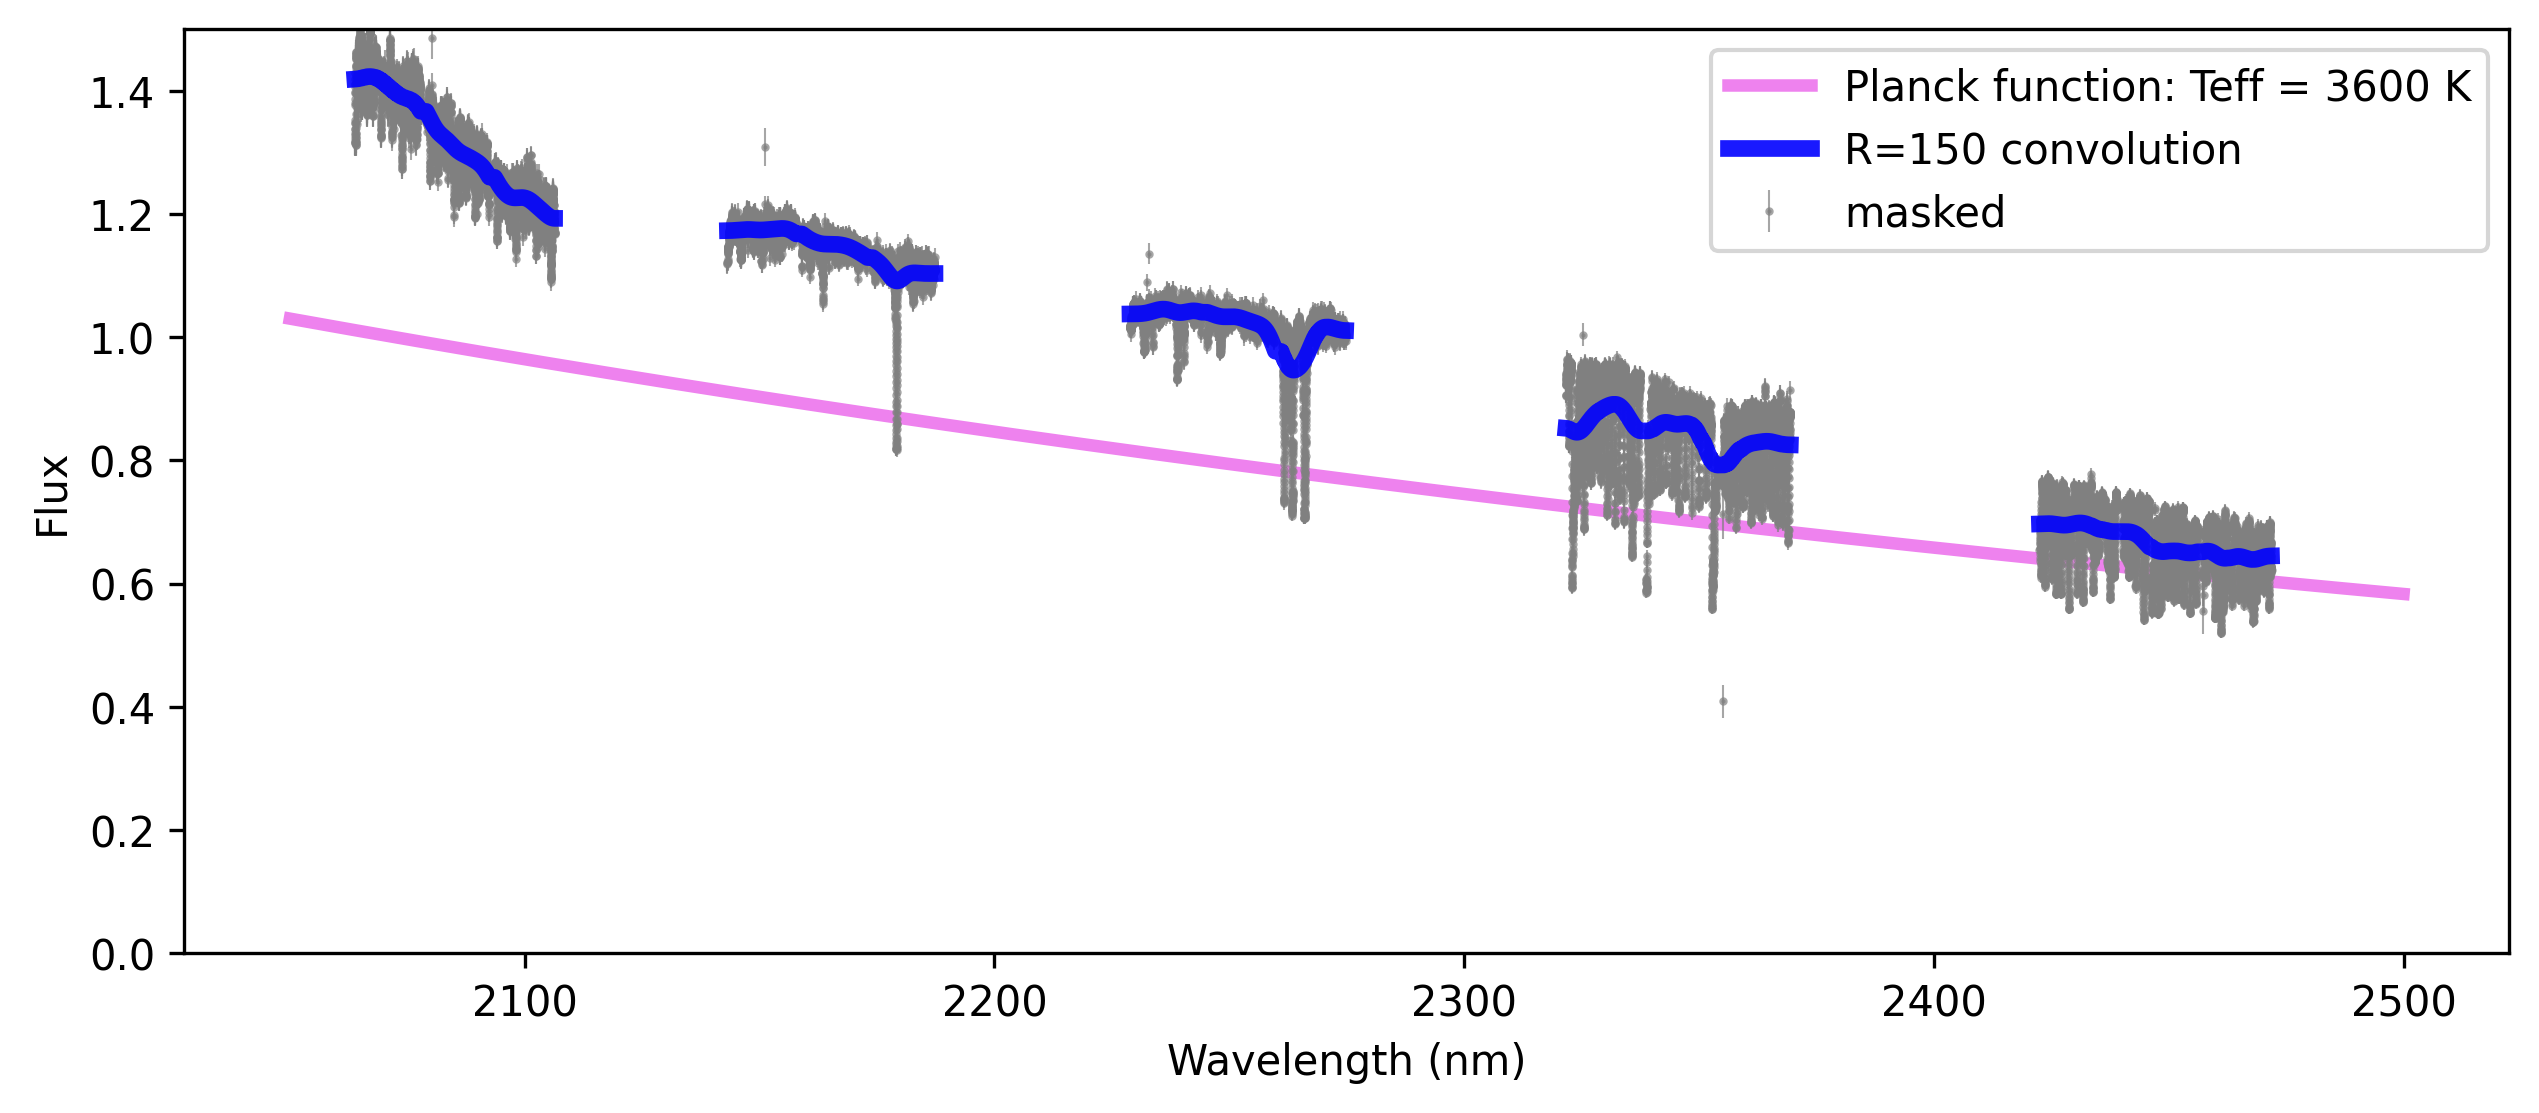

In [ ]:
plt.figure(figsize=(10, 4), dpi=300)

plt.plot(wl_planck_nm, planck_flux/1e11/5.3, linewidth=3, color='violet', label=f"Planck function: Teff = {teff} K")

n_dets = len(dets)

for i, iorder in enumerate(orders):
    # 注意这里用 i，而不是 iorder 本身
    chip_start = i * n_dets
    chip_end   = (i + 1) * n_dets

    wl_list = wave_chips[chip_start:chip_end]
    f_list  = flux_chips[chip_start:chip_end]
    e_list  = err_chips[chip_start:chip_end]

    # 原始 / masked 数据
    for j in range(n_dets):
        wl_chip = wl_list[j]
        f_chip  = f_list[j]
        e_chip  = e_list[j]

        plt.errorbar(
            wl_chip, f_chip/5.3, yerr=e_chip,
            fmt='o', color='grey', alpha=0.7, markersize=1, elinewidth=0.5,
            label='masked' if i == 0 and j == 0 else None,
        )
        print(f"wl_chip: {wl_chip.min()}, {wl_chip.max()}")

    # 把该 order 的 3 个 det 拼成一条长谱，按 order 级别做 LFP
    wl_all = np.concatenate(wl_list)
    f_all  = np.concatenate(f_list)
    e_all  = np.concatenate(e_list)

    for name, method in lfp_methods.items():
        wl_lfp_all, f_lfp_all, e_lfp_all = method(wl_all, f_all, e_all)
        plt.plot(
            wl_lfp_all, f_lfp_all/5.3,
            linewidth=4,
            label=lfp_labels[name] if i == 0 else None,
            color=lfp_colors[name],
            alpha=0.9,
            zorder=10,
        )

plt.ylim([0, 1.5])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Flux")
plt.legend()
plt.show()